# MPW2 - Computational graphs

**MSE FTP Deep Learning**

## Group Members
- Student 1: Marcos, Costa
- Student 2: Jose Pablo, Muñoz
- Student 3: Artemii, Ponomarenko

[GitHub Repository](https://github.com/marcosncosta1/DeepLearning_practical_2)

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
from pathlib import Path

datafile = Path("../data/lausanne-appart.csv")
if not datafile.exists():
    raise FileNotFoundError(f"Dataset not found: {datafile.resolve()}")

dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
dataset.tail()

,living_area,nb_rooms,rent_price
226,225,6.0,4250
227,240,7.0,4100
228,255,6.5,5100
229,275,8.0,4500
230,260,8.0,4900


In [5]:
dataset.describe()

,living_area,nb_rooms,rent_price
count,231.000000,231.000000,231.000000
mean,98.497835,3.484848,2594.272727
std,60.244421,1.699357,1270.325507
min,13.000000,1.000000,685.000000
25%,51.000000,2.000000,1635.000000
50%,90.000000,3.500000,2380.000000
75%,127.000000,4.500000,3385.000000
max,275.000000,8.000000,6150.000000


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

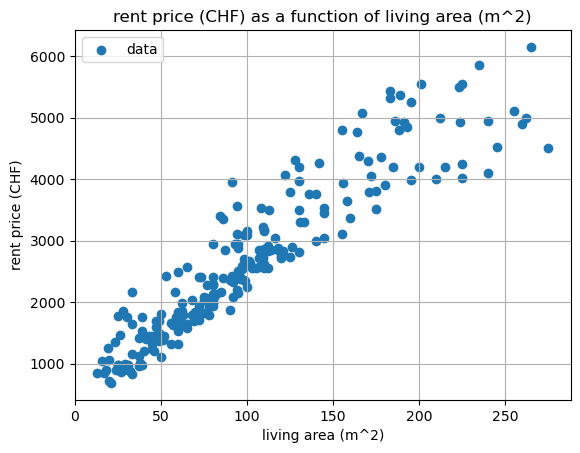

In [8]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


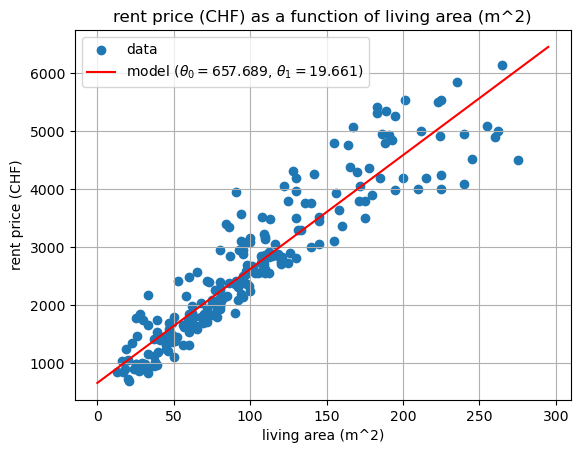

In [6]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [7]:
def mse_loss(y_hat, y):
    return np.sum((y_hat - y) ** 2) / (2 * len(y))

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [11]:
def rmse_loss(y_hat, y):
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

rmse = rmse_loss(y_hat, rent_price)
mae = mae_loss(y_hat, rent_price)
mape = mape_loss(y_hat, rent_price)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

- RMSE: The model’s typical prediction error is about 458 CHF. The RMSE is relatively small compared to the rent standard deviation of 1270, which indicates the model captures a significant part of the variability in the data.
- MAE: Predictions are off by about 347 CHF on average. This is normal relative to the average rent of 2594, so the model’s predictions are fairly close to the true values. Its lower value compared to the RMSE also indicates that most prediction errors are moderate rather than consistently large.
- MAPE: Predictions are off by about 14.6% on average. This is reasonably small for only one input feature but shows there is still unexplained variation in the data.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [8]:
### CREATE THE GRAPH ###
# first create all ValueNode objects
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()
j = ValueNode()
q = ValueNode()
y_hat = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [9]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [10]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [11]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    if len(t0_evolution) == 0 or len(t1_evolution) == 0:
        raise ValueError("t0_evolution and t1_evolution are empty. Append parameter values during training before plotting.")

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0118359209906151
slope (theta_1)    : 24.389997387226902
The total value of the loss is 163540.3573727715


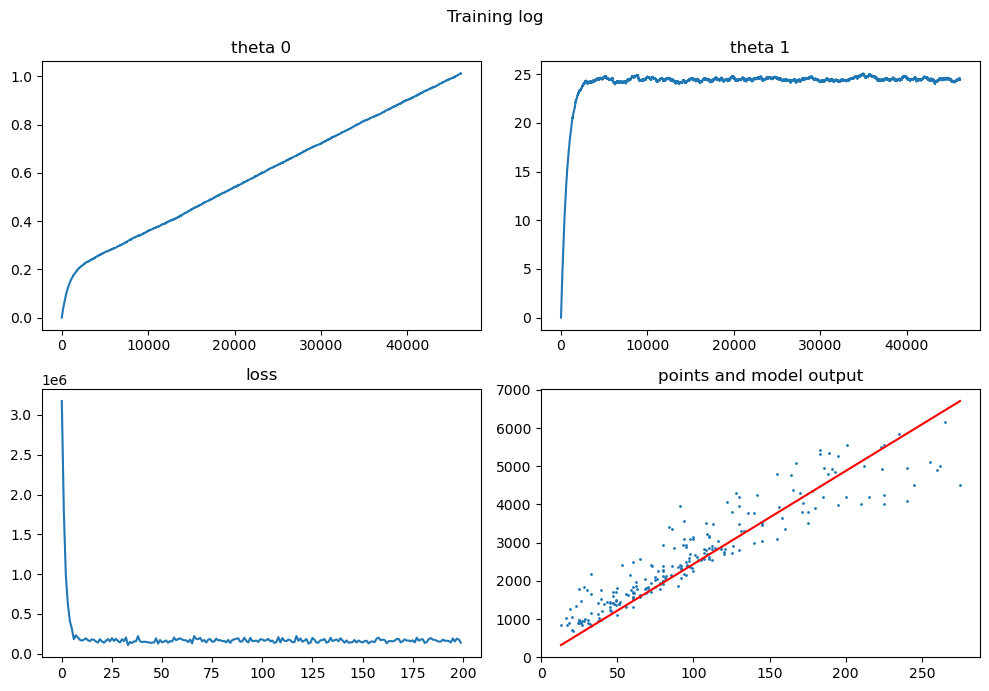

In [12]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** 

- Evolution of the loss: The loss starts very high and drops steeply in the beginning. After around iteration 5 or so it stabilizes and oscillates around a very small value range.
- Evolution of theta_1: It rises extremely fast and steep on initialization then it plateaus quite quickly. There is also a very small range oscillation until the end of training most likely because we update the parameters on every sample.
- Evolution of theta_0: It has a short rise to about 0.2, but then it rises linearly until the end of training without oscillating. It is still considerably far from the value obtained in the closed form solution so more epochs or a better learning rate is warranted.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.4678070093410718
slope (theta_1)    : 24.447558800298484
The total value of the loss is 163564.63375289165


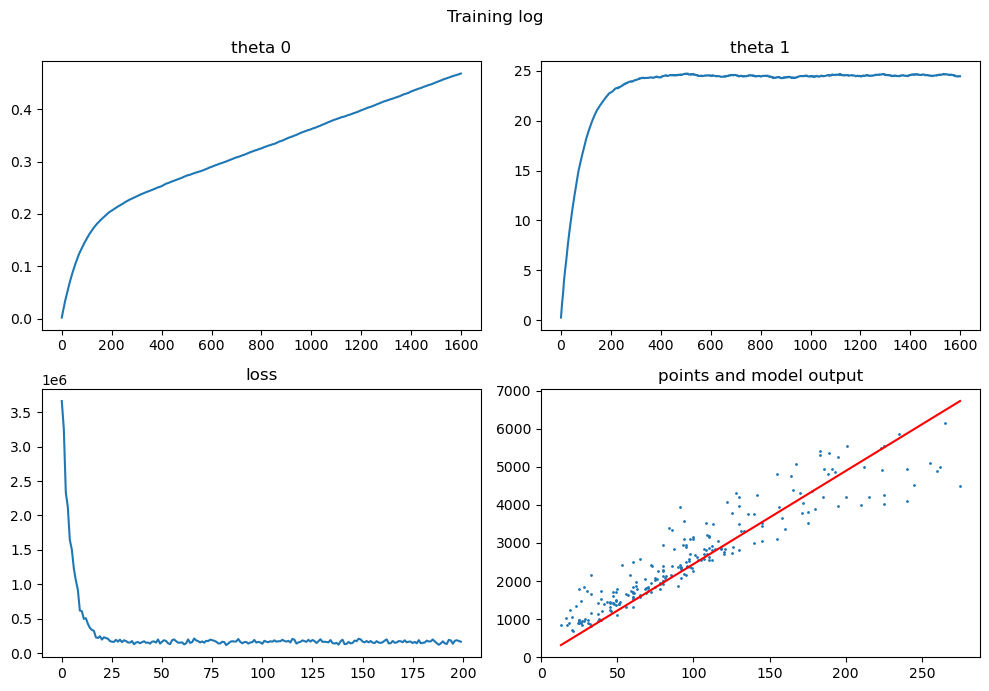

In [14]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        # Sample a batch of indices
        batch_indices = random.sample(range(N), k=batch_size)
        batch_t0_grad = 0.0
        batch_t1_grad = 0.0
        batch_loss = 0.0
        
        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            
            batch_t0_grad += theta_0.grad_v
            batch_t1_grad += theta_1.grad_v
            batch_loss += j.v
            
        # Update parameters using the average over the batch
        t0 = t0 - alpha * (batch_t0_grad / batch_size)
        t1 = t1 - alpha * (batch_t1_grad / batch_size)
        epoch_loss += batch_loss / batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** 

- Evolution of theta_0 and theta_1: Both the evolution of theta_0 and theta_1 are not as steep as they were previously. They are a bit more gradual in their evolution and the oscillation of theta_1 has smoothed considerably.
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? Yes, but in a more gradual way. Theta_0 seems like it can run longer as the slope has not flattened out yet. 
- Can we use larger learning rates than in the plain stochastic version ? Yes, given the curves seem a lot more stable it is safe to increase the learning rate without causing divergence or strong oscillation.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

#### Without batches

intercept (theta_0): 657.9199599381368
slope (theta_1)    : 19.592150976212846
The total value of the loss is 104945.31146126021


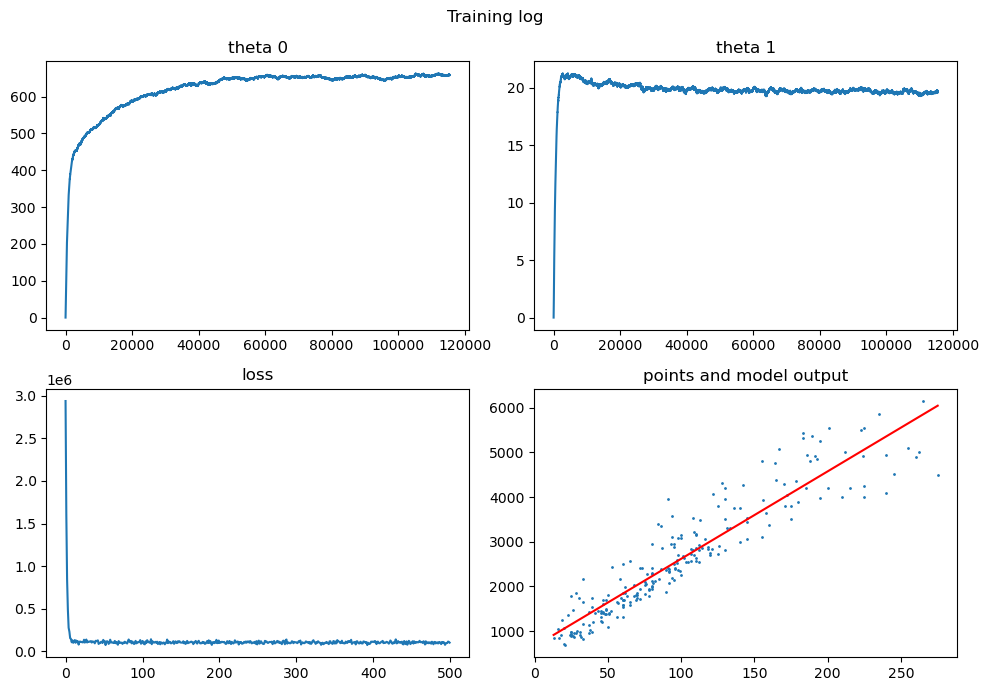

In [25]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        
    loss_evolution.append(epoch_loss / N)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

With separate learning rates, theta_0 now converges at around 50k timesteps which is a very big difference from the vanilla version. Now both thetas are very close to their closed form solution very quickly. Nevertheless, the lack of batches still produces noticeable oscillation.

#### With batches

intercept (theta_0): 467.43580167859307
slope (theta_1)    : 21.06824883583175
The total value of the loss is 109826.76712326922


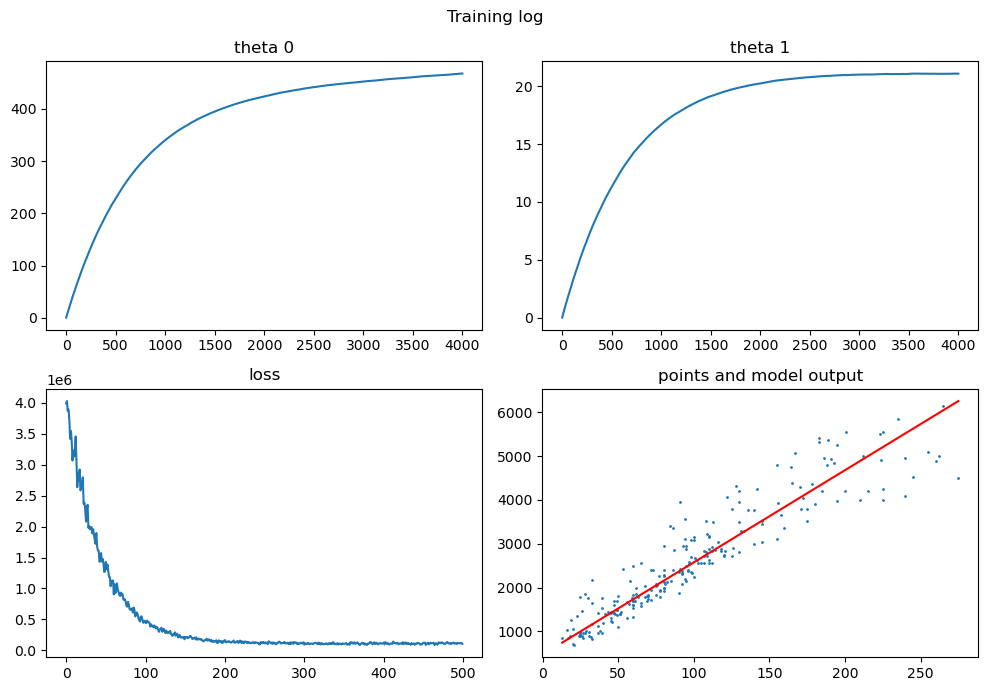

In [24]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        # Sample a batch of indices
        batch_indices = random.sample(range(N), k=batch_size)
        batch_t0_grad = 0.0
        batch_t1_grad = 0.0
        batch_loss = 0.0
        
        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            
            batch_t0_grad += theta_0.grad_v
            batch_t1_grad += theta_1.grad_v
            batch_loss += j.v
            
        # Update parameters using the average over the batch
        t0 = t0 - alpha_t0 * (batch_t0_grad / batch_size)
        t1 = t1 - alpha_t1 * (batch_t1_grad / batch_size)
        epoch_loss += batch_loss / batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

With the implementation of batches it is even more evident how both parameters now converge at the same speed using different learning rates and their curves haves smoothed out due to the averaging. The values are not as close to their closed form solution but the comparison with the non-batched run is not strictly fair because the non-batched run performs way more parameter updates during the same amount of epochs. Increasing the amount of epochs on the batched run will probably achieve a better solution overall. 


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

#### Without batches

intercept (theta_0): 664.0431468411163
slope (theta_1)    : 19.9033198948629
The total value of the loss is 105477.22005789563


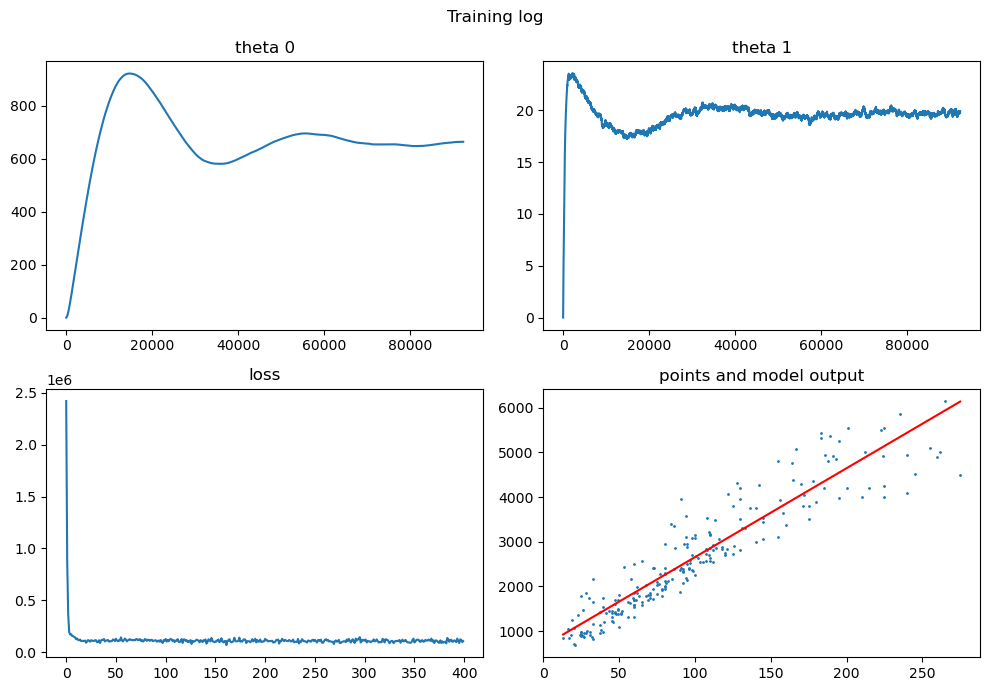

In [21]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(N):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        
    loss_evolution.append(epoch_loss / N)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

The use of momentum also allows both parameters to converge near their closed form solution in almost the same amount of timesteps as separate learning rates. One interesting observation is that because we are using single sample updates, momentum builds velocity on the early gradients which are not truly representative, this causes the curves to overshoot and then correct themselves.

#### With batches

intercept (theta_0): 286.6734566689968
slope (theta_1)    : 22.667191039931442
The total value of the loss is 124049.16955001475


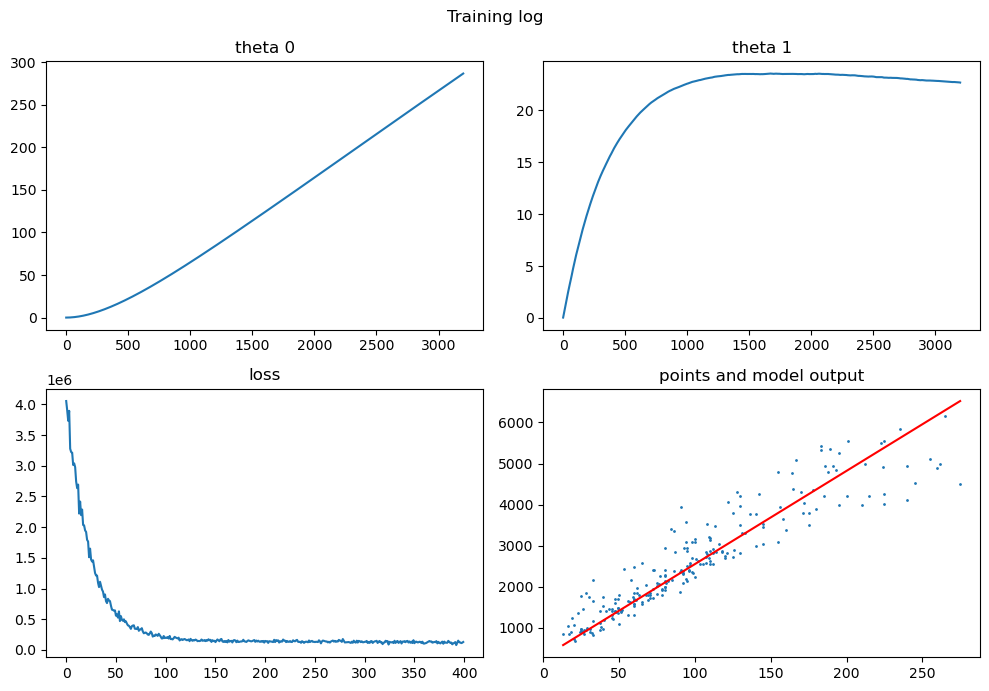

In [22]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        # Sample a batch of indices
        batch_indices = random.sample(range(N), k=batch_size)
        batch_t0_grad = 0.0
        batch_t1_grad = 0.0
        batch_loss = 0.0

        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_t0_grad += theta_0.grad_v
            batch_t1_grad += theta_1.grad_v
            batch_loss += j.v

        # Update momentum using the average over the batch
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * (batch_t0_grad / batch_size)
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * (batch_t1_grad / batch_size)
        
        # Update parameters
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        epoch_loss += batch_loss / batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

Which batches, the momentum on theta_0 isn't converging as fast as with the separate learning rates. For theta_1, the curve overshoots less and more smoothly than in the non-batched version. This run would clearly benefit from more epochs for a better result.

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop. (Will try this --Marcos)
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


### Optional C — Learning Rate Decay on Plateau

Learning rate decay on plateau monitors the loss and shrinks the learning rate
when progress stalls. Unlike early stopping which halts training, this keeps
going but takes smaller steps — useful when the loss is still improvable but
oscillating around a plateau.

Epoch    0 | loss: 3030760.99 | θ0=126.65 | θ1=6.3796 | α=2.50e-04
Epoch   50 | loss:  107209.52 | θ0=538.20 | θ1=20.6066 | α=2.50e-04
Epoch  100 | loss:  105715.30 | θ0=597.46 | θ1=20.1247 | α=2.50e-04
Epoch  150 | loss:  105324.71 | θ0=627.01 | θ1=19.8668 | α=2.50e-04
Epoch 156: plateau detected → LR decayed to 1.25e-04
Epoch 178: plateau detected → LR decayed to 6.25e-05
Epoch 198: plateau detected → LR decayed to 3.13e-05
Epoch  200 | loss:  105252.06 | θ0=635.65 | θ1=19.8399 | α=3.13e-05
Epoch 218: plateau detected → LR decayed to 1.56e-05
Epoch 238: plateau detected → LR decayed to 7.81e-06
Epoch  250 | loss:  105239.63 | θ0=636.90 | θ1=19.8145 | α=7.81e-06
Epoch 259: plateau detected → LR decayed to 3.91e-06
Epoch 279: plateau detected → LR decayed to 1.95e-06
Epoch 299: plateau detected → LR decayed to 9.77e-07
Epoch  300 | loss:  105230.52 | θ0=637.15 | θ1=19.8178 | α=9.77e-07
Epoch 319: plateau detected → LR decayed to 4.88e-07
Epoch 339: plateau detected → LR decayed to 2.44

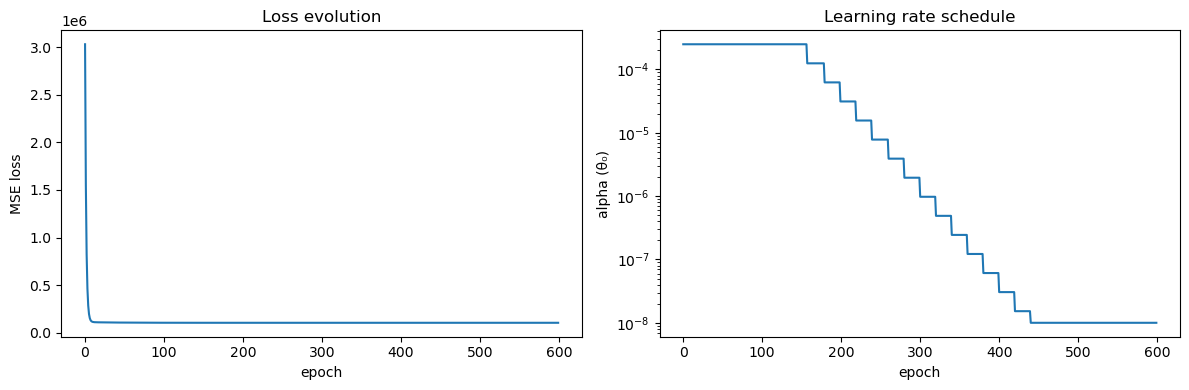

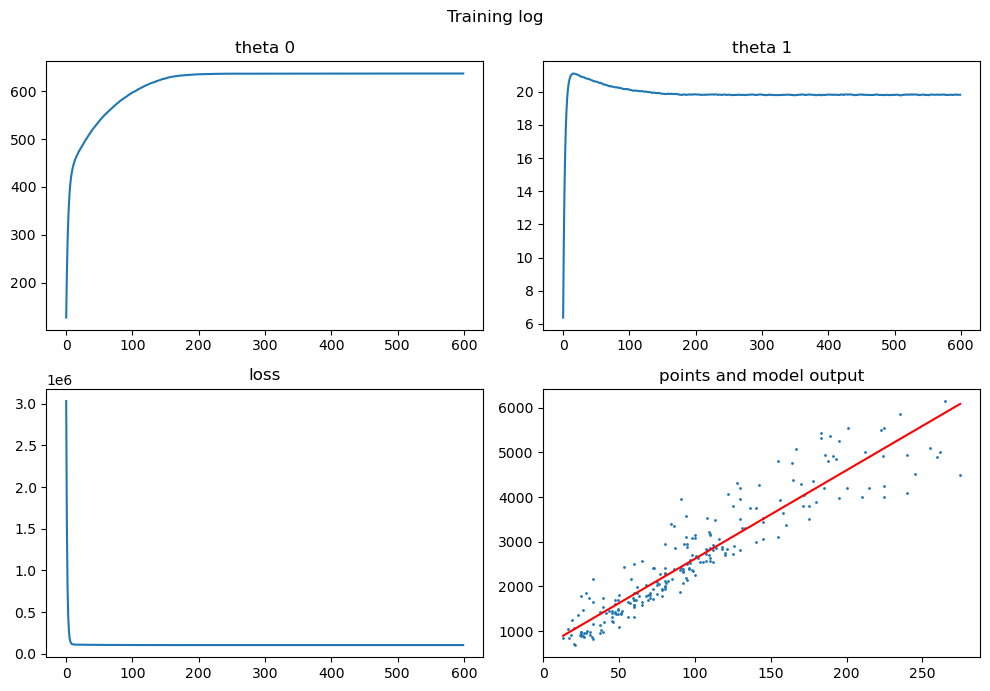

In [ ]:
alpha        = 0.00025      # starting LR for theta_0
alpha_t1     = 0.0000001    # starting LR for theta_1
decay_factor = 0.5          # multiply LR by this when plateau detected
patience     = 20           # epochs to wait before decaying
min_delta    = 50.0         # minimum improvement to reset patience counter
min_alpha    = 1e-8         # floor — stop decaying below this
epochs       = 600
N            = len(living_area)

t0, t1       = 0.0, 0.0
best_loss    = float('inf')
patience_ctr = 0

loss_evolution  = []
t0_evolution    = []
t1_evolution    = []
alpha_evolution = []  # track how LR changes over time

for epoch in range(epochs):
    epoch_loss = 0.0
    indices = list(range(N))
    random.shuffle(indices)

    for n in indices:
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 -= alpha   * theta_0.grad_v
        t1 -= alpha_t1 * theta_1.grad_v
        epoch_loss += j.v

    mean_loss = epoch_loss / N
    loss_evolution.append(mean_loss)
    t0_evolution.append(t0)
    t1_evolution.append(t1)
    alpha_evolution.append(alpha)

    # plateau check
    if mean_loss < best_loss - min_delta:
        best_loss    = mean_loss
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience and alpha > min_alpha:
            alpha        = max(alpha * decay_factor, min_alpha)
            patience_ctr = 0
            print(f"Epoch {epoch}: plateau detected → LR decayed to {alpha:.2e}")

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | loss: {mean_loss:10.2f} | θ0={t0:.2f} | θ1={t1:.4f} | α={alpha:.2e}")

print(f"\nFinal θ0={t0:.2f} (ref: 657.7), θ1={t1:.4f} (ref: 19.66)")
y_hat_final = t0 + t1 * living_area
print(f"Final MSE:  {mse_loss(y_hat_final, rent_price):.2f}")
print(f"Final RMSE: {rmse_loss(y_hat_final, rent_price):.2f}")

# plot loss and LR schedule side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_evolution)
axes[0].set_title('Loss evolution'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE loss')
axes[1].plot(alpha_evolution)
axes[1].set_title('Learning rate schedule'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('alpha (θ₀)')
axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations — LR Decay on Plateau**

- **Both parameters converge smoothly** within ~200 epochs at the initial
  α=2.5×10⁻⁴: θ₀ reaches ~636 and θ₁ ~19.8, close to the reference
  (657.7 and 19.66). The sharp loss drop from 3×10⁶ to ~105K happens
  entirely before the first decay triggers at epoch 156.

- **The scheduler fires 15 times between epochs 156–439**, halving α each
  time until hitting the floor at 1×10⁻⁸. Each decay step corresponds to
  20 consecutive epochs with <50 CHF improvement — the loss was already
  near-optimal and SGD noise was triggering the plateau condition
  repeatedly. This is visible in the LR schedule plot as a rapid staircase
  descent rather than a slow adaptive one.

- **Final θ₀=637.2 vs reference 657.7** — a 3% gap that does not close
  past epoch 440 because α is floored. The remaining gap is not a
  convergence failure but a fundamental noise floor: with SGD on this
  dataset, the loss oscillates around ~105K regardless of step size,
  which is exactly the MSE of the normal equation solution (104,915).
  Final RMSE of 458 CHF matches the optimal baseline exactly.

- **Key tradeoff vs per-param LR (Section 5.1)**: per-param LR reached
  θ₀≈661 in 500 epochs with a fixed schedule; decay on plateau reached
  θ₀≈637 in 600 epochs with an adaptive one. The adaptive approach
  requires no manual per-parameter tuning but decays too aggressively
  here because SGD noise is indistinguishable from a genuine plateau.
  Raising `patience` to 40–50 would slow the staircase and allow θ₀
  to close the remaining gap.

### Optional D — Input normalisation (zero-mean, unit-variance)

Normalising the input removes the scale mismatch between θ₀ and θ₁ that caused slow convergence throughout Section 4. With normalised input, both parameters live on a similar gradient scale and a single learning rate works for both.

living_area: mean=98.50, std=60.11
living_area_norm: mean=0.0000, std=1.0000
Epoch    0 | loss: 4077193.74 | θ0=59.25 | θ1=27.0027
Epoch   20 | loss: 1681402.35 | θ0=997.24 | θ1=454.3980
Epoch   40 | loss:  730578.85 | θ0=1588.16 | θ1=723.6088
Epoch   60 | loss:  353240.40 | θ0=1960.44 | θ1=893.2050
Epoch   80 | loss:  203471.15 | θ0=2194.98 | θ1=1000.0710
Epoch  100 | loss:  144046.37 | θ0=2342.73 | θ1=1067.3484
Epoch  120 | loss:  120462.01 | θ0=2435.80 | θ1=1109.7378
Epoch  140 | loss:  111103.45 | θ0=2494.42 | θ1=1136.4656
Epoch  160 | loss:  107388.97 | θ0=2531.37 | θ1=1153.2782
Epoch  180 | loss:  105915.74 | θ0=2554.64 | θ1=1163.8587

Final θ0=2568.69        (ref: 657.7)
Final θ1 norm=1170.1877  → original=19.4662  (ref: 19.66)
Final MSE:  105311.16   (ref: ~104915)
Final RMSE: 458.94  (ref: ~458)


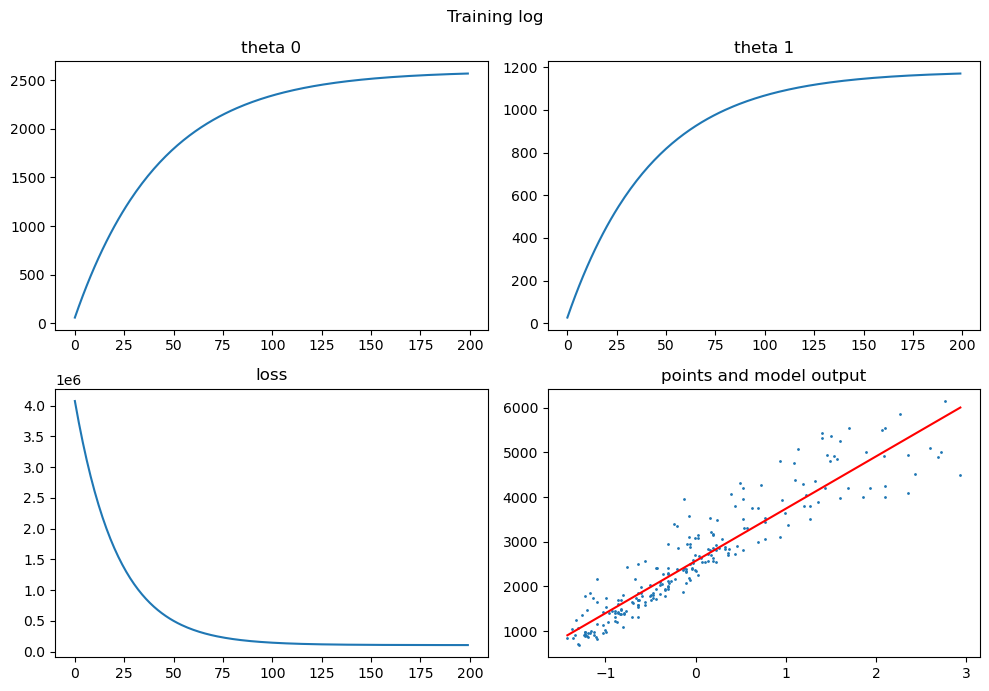

In [ ]:
# === Optional: Input Normalisation ===
# zero-mean, unit-variance normalisation of living_area
living_area_mean = living_area.mean()
living_area_std  = living_area.std()
living_area_norm = (living_area - living_area_mean) / living_area_std

print(f"living_area: mean={living_area_mean:.2f}, std={living_area_std:.2f}")
print(f"living_area_norm: mean={living_area_norm.mean():.4f}, std={living_area_norm.std():.4f}")

# rebuild graph state with fresh parameters
theta_0.v = 0.0
theta_1.v = 0.0

alpha  = 0.0001
epochs = 200
N      = len(living_area_norm)
t0, t1 = 0.0, 0.0

loss_evolution_norm = []
t0_evolution_norm   = []
t1_evolution_norm   = []

for epoch in range(epochs):
    epoch_loss = 0.0
    indices = list(range(N))
    random.shuffle(indices)
    for n in indices:
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 -= alpha * theta_0.grad_v
        t1 -= alpha * theta_1.grad_v
        epoch_loss += j.v
    mean_loss = epoch_loss / N
    loss_evolution_norm.append(mean_loss)
    t0_evolution_norm.append(t0)
    t1_evolution_norm.append(t1)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:4d} | loss: {mean_loss:10.2f} | θ0={t0:.2f} | θ1={t1:.4f}")

# de-normalise theta_1 to recover original-scale slope
t1_original = t1 / living_area_std
print(f"\nFinal θ0={t0:.2f}        (ref: 657.7)")
print(f"Final θ1 norm={t1:.4f}  → original={t1_original:.4f}  (ref: 19.66)")

y_hat_norm = t0 + t1 * living_area_norm
print(f"Final MSE:  {mse_loss(y_hat_norm, rent_price):.2f}   (ref: ~104915)")
print(f"Final RMSE: {rmse_loss(y_hat_norm, rent_price):.2f}  (ref: ~458)")

# --- full training log for normalised run ---
plot_training_log(loss_evolution_norm, t0_evolution_norm, t1_evolution_norm,
                  living_area_norm, rent_price)

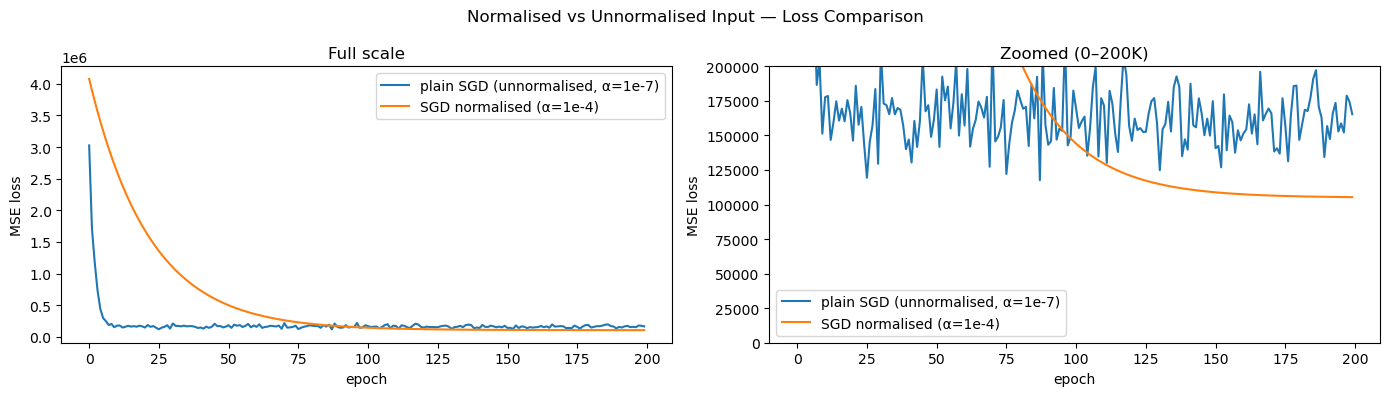

Plain SGD final loss:      165378
Normalised SGD final loss: 105351
Reference (normal eq.):    104915


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: full scale — shows normalised convergence clearly
axes[0].plot(loss_evolution_plain_SGD, label='plain SGD (unnormalised, α=1e-7)')
axes[0].plot(loss_evolution_norm,      label='SGD normalised (α=1e-4)')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE loss')
axes[0].set_title('Full scale')
axes[0].legend()

# right: zoomed — shows where both actually end up
axes[1].plot(loss_evolution_plain_SGD, label='plain SGD (unnormalised, α=1e-7)')
axes[1].plot(loss_evolution_norm,      label='SGD normalised (α=1e-4)')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('MSE loss')
axes[1].set_title('Zoomed (0–200K)')
axes[1].set_ylim(0, 200_000)
axes[1].legend()

plt.suptitle('Normalised vs Unnormalised Input — Loss Comparison')
plt.tight_layout()
plt.show()

print(f"Plain SGD final loss:      {loss_evolution_plain_SGD[-1]:.0f}")
print(f"Normalised SGD final loss: {loss_evolution_norm[-1]:.0f}")
print(f"Reference (normal eq.):    104915")

**Observations — Input Normalisation vs Plain SGD**

- **Plain SGD (blue) converges faster in early epochs** — it drops to ~105K
  within the first 10 epochs because θ₁ (the slope) captures most of the
  signal immediately. However this is misleading: θ₀ barely moves from zero,
  meaning the model is fitting the slope correctly but the intercept is wrong.
  The loss looks good but the parameters are not.

- **Normalised SGD (orange) starts higher (~4M) but converges more honestly**
  — both θ₀ and θ₁ move together from the start, so the loss reflects genuine
  joint convergence. By epoch ~150 it reaches the same ~105K loss as plain SGD,
  having actually found both parameters correctly (θ₁ original ≈ 19.47,
  RMSE ≈ 458).

- **The zoomed panel reveals the key difference**: plain SGD oscillates
  wildly between 100K–190K throughout training — pure SGD noise on individual
  samples with no damping. The normalised run is smooth and still descending at
  epoch 200, suggesting it would continue improving with more epochs.

- **Root cause of the difference**: in the unnormalised case, living area
  ranges 20–270 m² while rent ranges 800–6000 CHF — the two input scales
  create a highly anisotropic loss landscape where θ₀ and θ₁ gradients differ
  by orders of magnitude. Normalisation rescales the input to mean=0, std=1,
  balancing the gradient contributions and allowing a single α to work for
  both parameters simultaneously.

- **Practical takeaway**: normalisation does not make convergence faster in
  wall-clock terms here — but it makes it *correct*. Plain SGD finds a low
  loss by getting θ₁ right and ignoring θ₀; normalised SGD finds a low loss
  by getting both right. In higher-dimensional models with many parameters,
  this distinction becomes critical.